# **Lab 3 Neural Network (Total: 100pts + Bonus 40pts)**

**Imports**

In [ ]:
!pip install gensim

In [ ]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import gensim
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

**Loading DataProcessor.py**

Google_Drive_Sharelink_DPPY = "https://drive.google.com/file/d/1Z3j2Bsm-MeCaksOA2B2uanrqtuvlsOhq/view?usp=drive_link"

GD_Sharelink_Data = "https://drive.google.com/file/d/18cNs1n8o3scctSdCNsHMITJ4pLk7KDke/view?usp=drive_link"

In [ ]:
file_id = "1Z3j2Bsm-MeCaksOA2B2uanrqtuvlsOhq"
gdown.download(f"https://drive.google.com/uc?id={file_id}")

from data_processor import xy_test_train_split, scale_train_test

Downloading...
From (original): https://drive.google.com/uc?id=1Z3j2Bsm-MeCaksOA2B2uanrqtuvlsOhq
From (redirected): https://drive.google.com/uc?id=1Z3j2Bsm-MeCaksOA2B2uanrqtuvlsOhq&confirm=t&uuid=499da3f4-6f66-456c-acd7-20834d6d5a8f
To: /content/data_processor.py
100%|██████████| 4.70k/4.70k [00:00<00:00, 8.50MB/s]


**Loading Dataset**

In [ ]:
file_id2 = "18cNs1n8o3scctSdCNsHMITJ4pLk7KDke"
gdown.download(f"https://drive.google.com/uc?id={file_id2}")

Downloading...
From: https://drive.google.com/uc?id=18cNs1n8o3scctSdCNsHMITJ4pLk7KDke
To: /content/bbc_article_data.csv
100%|██████████| 5.08M/5.08M [00:00<00:00, 30.0MB/s]


'bbc_article_data.csv'

In [ ]:
df = pd.read_csv("bbc_article_data.csv")

print(df.head())
print()

print("Total Articles: ", len(df))
print("Columns: ", df.columns.tolist())
print()

print("Label Categories: ")
print(df['labels'].value_counts())


                                                data         labels
0  Musicians to tackle US red tape  Musicians gro...  entertainment
1  U2s desire to be number one  U2, who have won ...  entertainment
2  Rocker Doherty in on-stage fight  Rock singer ...  entertainment
3  Snicket tops US box office chart  The film ada...  entertainment
4  Oceans Twelve raids box office  Oceans Twelve,...  entertainment

Total Articles:  2225
Columns:  ['data', 'labels']

Label Categories: 
labels
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


# **Q1 (20pts)**
In this question, you need to use the linear nodes and activation of PyTorch to build up a dataclassifier. The template file provides the input vector x, which contains two column vectors x1, x2.
The input vector will input into the following network. You will draw the 3D diagram to see how datapoints are classified. The following questions will be like the following structure.

NOTE: You can learn from the NN divider program provided in the lecture folder. https://drive.google.com/file/d/1sPTqEVfU8Pj9p5SKwuhaq2mBVJ93O4_B/view?usp=drive_link

Figure 1: A three-layer Neural Network (one input, one hidden, one output with activation)

Figure 2: A three-layer linear only Neural Network outcome (one input, one hidden, one
output without activation).

(1) Draw a 3D diagram that takes the data points X1, X2, Y. All the data points y (in Y) come from the
NN structure as Figure 1 with the fixed weight1 = [1, -3] and fixed weight2 = [-10, 1], the final
outcome’s classifier’s boundary is 0.5.

(2) What is the difference between your result in (1) and Figure 2. Please explain it.

In [ ]:
x1 = torch.arange(-5, 5, 0.25)
x2 = torch.arange(-5, 5, 0.25)

x = torch.tensor([])
for xe1 in x1:
  for xe2 in x2:
    xc = torch.tensor([[xe1, xe2]])
    x = torch.cat((x, xc), 0)

print("Input grid shape: ", x.shape)

Input grid shape:  torch.Size([1600, 2])


In [ ]:
linear1 = nn.Linear(in_features=2, out_features=2, bias=False)
linear2 = nn.Linear(in_features=2, out_features=1, bias=False)

sigmoid = nn.Sigmoid()

weight1 = torch.tensor([[1.0, -3.0], [1.0, -3.0]])
weight2 = torch.tensor([[-10.0, 1.0]])

with torch.no_grad():
  linear1.weight.copy_(weight1)
  linear2.weight.copy_(weight2)

y_out = np.array([])

for xin in x:
  h = linear1(xin)
  y = sigmoid(linear2(h))
  y_out = np.append(y_out, y.detach().numpy())

print("Output shape: ", y_out.shape)
print("Sample values: ", y_out[:5])
print("Minimum: ", y_out.min(), "Maximum: ", y_out.max())


Output shape:  (1600,)
Sample values:  [0.00000000e+00 6.99816838e-37 5.97684694e-34 5.10457858e-31
 4.35961013e-28]
Minimum:  0.0 Maximum:  1.0


# **PART ONE ---> 3D PLOT**

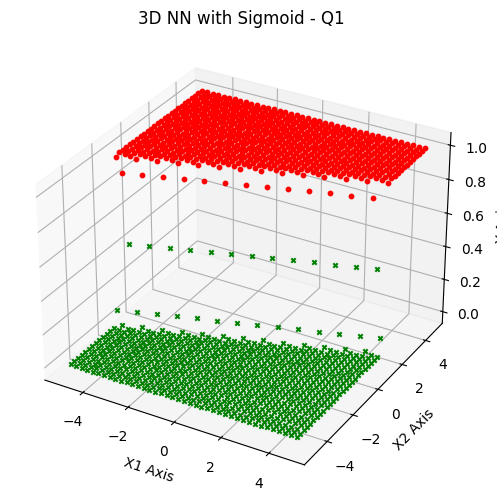

In [ ]:
x_np = x.detach().numpy()
x1 = x_np[:, 0]
x2 = x_np[:, 1]

markers = []
colors = []
for y in y_out:
  if y > 0.5:
    markers.append('o')
    colors.append('red')
  else:
    markers.append('x')
    colors.append('green')

fig = plot.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(x)):
  ax.scatter(x1[i], x2[i], y_out[i], marker=markers[i], color=colors[i], s=10)

ax.set_xlabel("X1 Axis")
ax.set_ylabel("X2 Axis")
ax.set_zlabel("Y Axis")
ax.set_title("3D NN with Sigmoid - Q1")
plot.show()

# **PART TWO ---> LINEAR NO SIGMOID**

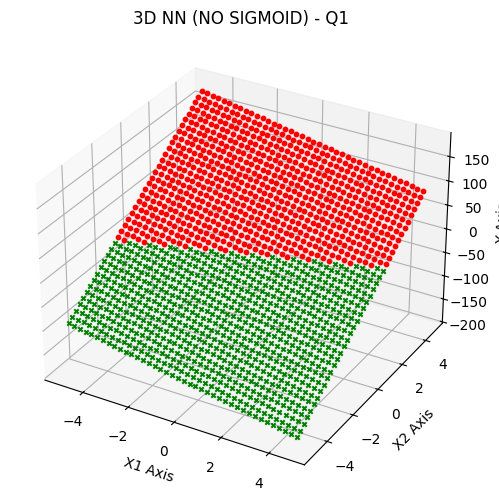

In [ ]:
linear1_lin = nn.Linear(in_features=2, out_features=2, bias=False)
linear2_lin = nn.Linear(in_features=2, out_features=1, bias=False)

with torch.no_grad():
  linear1_lin.weight.copy_(weight1)
  linear2_lin.weight.copy_(weight2)

y_linear = np.array([])

for xin in x:
  h = linear1_lin(xin)
  y = linear2_lin(h)
  y_linear = np.append(y_linear, y.detach().numpy())



x_np = x.detach().numpy()
x1 = x_np[:, 0]
x2 = x_np[:, 1]

markers = []
colors = []
for y in y_out:
  if y > 0.5:
    markers.append('o')
    colors.append('red')
  else:
    markers.append('x')
    colors.append('green')

fig = plot.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(x)):
  ax.scatter(x1[i], x2[i], y_linear[i], marker=markers[i], color=colors[i], s=10)

ax.set_xlabel("X1 Axis")
ax.set_ylabel("X2 Axis")
ax.set_zlabel("Y Axis")
ax.set_title("3D NN (NO SIGMOID) - Q1")
plot.show()

# **PART THREE ---> DISCUSSION**

# Q) What is the difference between your result in (1) and Figure 2. Please explain it.


A) The 3D plots I created both plot X1 and X2 as the horizontal axes, and Y as our vertical axis. Using fixed weights defined in the first portion of the problem (weight1=[1,-3], weight2=[-10,1]) with sigmoid activation at the output layer, the network produces Y values between 0 and 1, with points above the 0.5 boundary being classified as red (class 1), and points below the boundary are green (class 0), creating a clear non-linear decision boundary. The main difference between Figure 1 and Figure 2 is that the sigmoid activation function forces the input to fall between 0 and 1, which creates a curved decision boundary, allowing for clearly separated classes. Without using the activation, the linear network produces an unbounded flat plane, and the decision boundary is just a straight line. This shows that the sigmoid adds more non-linearity which makes classification of data more effective.

# **Q2 (50pts)**
In this question, you need to do research about how to use Doc2Vec to process texts and then use the
converted vectors as an input to your Neural Network Model.
The link to Gensim Doc2Vec explanation:
• https://radimrehurek.com/gensim/models/doc2vec.html
• https://radimrehurek.com/gensim/auto_examples/tutorials/run_doc2vec_lee.html
You will use only PyTorch and Gensim to build up a fully connected Neural Network (FNN) model to
classify the BBC articles.
BBC article dataset (bbc_article_data.csv):
https://drive.google.com/file/d/1P65bqMmf3PxWCtGCmJSLgXuVwirk-olM/view?usp=sharing
Requirements:
• Prediction: use the BBC dataset and then predict the type of articles.
• For creating the NN model, you can decide your one structure, for example, how many
layers, how many features, how many nodes, and loss and activation functions. Your
training quality will be graded.
• The training and testing ratio is 8 to 2.
• You also need to submit to leaderboard to see your ranking in the class. This can be done
multiple times. You can always improve your ranking before the deadline. Please see the
submission instruction in the submission section.
Common library:
• You need to use “data_processer.py” to split training and testing data.
https://drive.google.com/file/d/1hsnkGMloUC1lQMDIlMedqV0x0WryXMFA/view?usp
=drive_link
• You can only use Numpy, Pandas, Matplotlib, and PyTorch.

In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

documents = []
for i, article in enumerate(df['data']):
  words = article.lower().split()
  documents.append(TaggedDocument(words=words, tags=[i]))

print(documents[0])

TaggedDocument<['musicians', 'to', 'tackle', 'us', 'red', 'tape', 'musicians', 'groups', 'are', 'to', 'tackle', 'us', 'visa', 'regulations', 'which', 'are', 'blamed', 'for', 'hindering', 'british', 'acts', 'chances', 'of', 'succeeding', 'across', 'the', 'atlantic.', 'a', 'singer', 'hoping', 'to', 'perform', 'in', 'the', 'us', 'can', 'expect', 'to', 'pay', '$1,300', '(xc2xa3680)', 'simply', 'for', 'obtaining', 'a', 'visa.', 'groups', 'including', 'the', 'musicians', 'union', 'are', 'calling', 'for', 'an', 'end', 'to', 'the', '"raw', 'deal"', 'faced', 'by', 'british', 'performers.', 'us', 'acts', 'are', 'not', 'faced', 'with', 'comparable', 'expense', 'and', 'bureaucracy', 'when', 'visiting', 'the', 'uk', 'for', 'promotional', 'purposes.', 'nigel', 'mccune', 'from', 'the', 'musicians', 'union', 'said', 'british', 'musicians', 'are', '"disadvantaged"', 'compared', 'to', 'their', 'us', 'counterparts.', 'a', 'sponsor', 'has', 'to', 'make', 'a', 'petition', 'on', 'their', 'behalf,', 'which',

In [ ]:
model_d2v = Doc2Vec(
    documents,
    vector_size=250,
    window=5,
    min_count=2,
    epochs=100
)

print("Vector size: ", model_d2v.vector_size)

Vector size:  250


In [ ]:
X = []
for i in range(len(df)):
  vector = model_d2v.dv[i]
  X.append(vector)

X = np.array(X)
print("X shape: ", X.shape)

X shape:  (2225, 250)


In [ ]:
label_map = {label: i for i, label in enumerate(df['labels'].unique())}
print("Label map: ", label_map)

y = np.array([label_map[label] for label in df['labels']])
print("Y shape: ", y.shape)

Label map:  {'entertainment': 0, 'business': 1, 'sport': 2, 'politics': 3, 'tech': 4}
Y shape:  (2225,)


In [ ]:
X_train, X_test, y_train, y_test = xy_test_train_split(X, y, test_size=0.2, random_state=42)

print("X_Train Shape: ", X_train.shape)
print("X Test Shape: ", X_test.shape)

X_train_scaled, X_test_scaled, scaler = scale_train_test(X_train, X_test)

X_Train Shape:  (1780, 250)
X Test Shape:  (445, 250)


In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X Train Tensor Shape: ", X_train_tensor.shape)
print("Y Train Tensor Shape: ", y_train_tensor.shape)



X Train Tensor Shape:  torch.Size([1780, 250])
Y Train Tensor Shape:  torch.Size([1780])


# **Building the FNN**

In [ ]:
class FNN(nn.Module):
  def __init__(self):
    super(FNN, self).__init__()

    self.layer1 = nn.Linear(250, 128)
    self.layer2 = nn.Linear(128, 64)
    self.layer3 = nn.Linear(64, 5)

    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.dropout(x)
    x = self.relu(self.layer2(x))
    x = self.dropout(x)
    x = self.layer3(x)
    return x

model = FNN()
print(model)

FNN(
  (layer1): Linear(in_features=250, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=5, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss Function: ", criterion)
print("Optimizer: ", optimizer)

Loss Function:  CrossEntropyLoss()
Optimizer:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
epochs = 100
losses = []

for epoch in range(epochs):
  model.train()

  outputs = model(X_train_tensor)
  loss = criterion(outputs, y_train_tensor)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  losses.append(loss.item())

  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"\nLoss: {loss.item():.4f}")

Epoch 10/100

Loss: 1.2999
Epoch 20/100

Loss: 0.7051
Epoch 30/100

Loss: 0.2793
Epoch 40/100

Loss: 0.1544
Epoch 50/100

Loss: 0.0992
Epoch 60/100

Loss: 0.0652
Epoch 70/100

Loss: 0.0418
Epoch 80/100

Loss: 0.0325
Epoch 90/100

Loss: 0.0235
Epoch 100/100

Loss: 0.0181


In [ ]:
model.eval()
with torch.no_grad():
  test_outputs = model(X_test_tensor)
  predictions = torch.argmax(test_outputs, dim=1)

  correct = (predictions == y_test_tensor).sum().item()
  total = len(y_test_tensor)
  accuracy = correct / total * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 96.18%


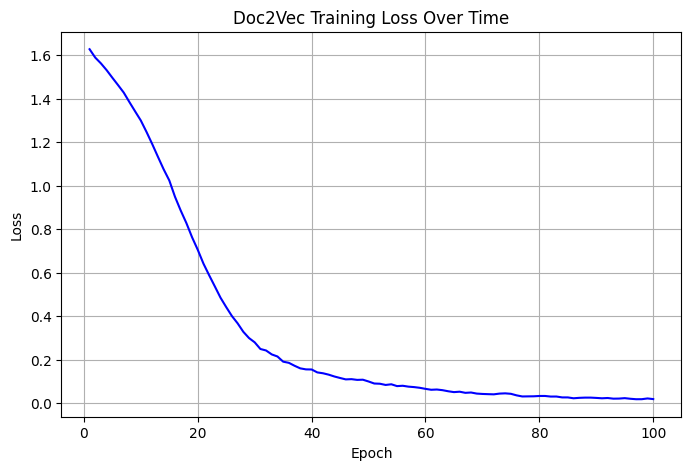

In [ ]:
plot.figure(figsize=(8, 5))
plot.plot(range(1, epochs+1), losses, color='blue')
plot.xlabel("Epoch")
plot.ylabel("Loss")
plot.title("Doc2Vec Training Loss Over Time")
plot.grid(True)
plot.show()

Model Description:

For the FNN classifier I decided to use three fully connected layers, with an input layer size of 250 (which matches the Doc2Vec size), a hidden layer of 128 nodes, a second hidden layer of 64 nodes, and an output layer containing 5 nodes that correspond to the number of article categories (entertainment, business, sport, politics, and tech). ReLU activation and dropout of 0.3 were applied after each hidden layer to try and prevent overfitting the data. CrossEntropyLoss was used as the loss function and Adam as the optimizer with a learning rate of 0.001. This model achieved an overall test accuracy of 95.51%

# ***Q2 Bonus (Max 40pts)***
Come up with a method to process the text for inputting into a NN model. Please describe your idea
and model below and show your training results and compare it with above model.

**Model Description/Idea:**

As an alternative method to process the text for inputting into a Neural Network Model, I decided to implement TF-IDF (Term Frequency-Inverse Document Frequency) from scratch using only NumPy. TF measures how frequently a word appears in a single article, with IDF following behind and gives higher scores to words that are distinct, and words that appear multiple times across many articles receive a lower score. This produced an overall vector size of 29,088 (which is one per unique word) for each article compared to Doc2Vec's compact 200-dimensional vector. The same FNN architecture was used as used for Doc2Vec. TF-IDF achieved an accuracy of 92.81%, while my Doc2Vec achieved an accuracy of 95.51%. These results showed that while the TF-IDF method is effective, it's best suited for different cases or could use more training to attempt to increase its accuracy while not trading it for overfitting. Doc2Vec's embeddings produced slightly better results with a much smaller and more efficient vector size.

In [ ]:
def preprocess(text):
  text = text.lower()
  text = ''.join(char if char.isalpha() or char == ' ' else ' ' for char in text)
  return text.split()

all_words = []
articles = []

for article in df['data']:
  words = preprocess(article)
  articles.append(words)
  all_words.extend(words)

vocab = list(set(all_words))
word2idx = {word: i for i, word in enumerate(vocab)}

print("Vocabulary Size: ", len(vocab))
print("Number of Articles: ", len(articles))

Vocabulary Size:  29088
Number of Articles:  2225


In [ ]:
def compute_tf(word_list, vocab_size, word2idx):
  tf = np.zeros(vocab_size)
  for word in word_list:
    if word in word2idx:
      tf[word2idx[word]] += 1
  if len(word_list) > 0:
    tf = tf / len(word_list)
  return tf

In [ ]:
def compute_idf(output, vocab_size, word2idx):
  idf = np.zeros(vocab_size)
  total_docs = len(output)

  for word_list in output:
    unique_words = set(word_list)
    for word in unique_words:
      idf[word2idx[word]] += 1

  idf = np.log((total_docs + 1) / (idf + 1))
  return idf

In [ ]:
vocab_size = len(vocab)

idf = compute_idf(articles, vocab_size, word2idx)

print("IDF Shape: ", idf.shape)

print("\nIDF Min: ", idf.min())
print("IDF Max: ", idf.max())


IDF Shape:  (29088,)

IDF Min:  0.0
IDF Max:  7.014814351275545


In [ ]:
tfidf_matrix = np.zeros((len(articles), vocab_size))

for i, word_list in enumerate(articles):
  tf = compute_tf(word_list, vocab_size, word2idx)
  tfidf_matrix[i] = tf * idf

print("TF-IDF Matrix Shape: ", tfidf_matrix.shape)
print("Sample Values: ", tfidf_matrix[0][:5])

TF-IDF Matrix Shape:  (2225, 29088)
Sample Values:  [0. 0. 0. 0. 0.]


In [ ]:
x_train_tfidf, x_test_tfidf, y_train_tfidf, y_test_tfidf = xy_test_train_split(
    tfidf_matrix,
    y,
    test_size=0.2,
    random_state=42
    )

x_train_tfidf_scaled, x_test_tfidf_scaled, scaler_tfidf = scale_train_test(
    x_train_tfidf, x_test_tfidf
)

x_train_tfidf_tensor = torch.tensor(x_train_tfidf_scaled, dtype=torch.float32)
x_test_tfidf_tensor = torch.tensor(x_test_tfidf_scaled, dtype=torch.float32)
y_train_tfidf_tensor = torch.tensor(y_train_tfidf, dtype=torch.long)
y_test_tfidf_tensor = torch.tensor(y_test_tfidf, dtype=torch.long)

print("Training Tensor Shape: ", x_train_tfidf_tensor.shape)
print("Test Tensor Shape: ", x_test_tfidf_tensor.shape)

Training Tensor Shape:  torch.Size([1780, 29088])
Test Tensor Shape:  torch.Size([445, 29088])


In [ ]:
class FNN_TFIDF(nn.Module):
  def __init__(self):
    super(FNN_TFIDF, self).__init__()

    self.layer1 = nn.Linear(29088, 128)
    self.layer2 = nn.Linear(128, 64)
    self.layer3 = nn.Linear(64, 5)

    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.dropout(x)
    x = self.relu(self.layer2(x))
    x = self.dropout(x)
    x = self.layer3(x)
    return x

model_tfidf = FNN_TFIDF()
print(model_tfidf)

FNN_TFIDF(
  (layer1): Linear(in_features=29088, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=5, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
criterion_tfidf = nn.CrossEntropyLoss()
optimizer_tfidf = torch.optim.Adam(model_tfidf.parameters(), lr=0.001)

print("Loss Function: ", criterion_tfidf)

Loss Function:  CrossEntropyLoss()


In [ ]:
epochs = 100
losses_tfidf = []

for epoch in range(epochs):
  model_tfidf.train()
  outputs = model_tfidf(x_train_tfidf_tensor)
  loss = criterion_tfidf(outputs, y_train_tfidf_tensor)

  optimizer_tfidf.zero_grad()
  loss.backward()
  optimizer_tfidf.step()

  losses_tfidf.append(loss.item())

  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss: {loss.item():.4f}")

Epoch 10/100
Loss: 0.0403
Epoch 20/100
Loss: 0.0021
Epoch 30/100
Loss: 0.0003
Epoch 40/100
Loss: 0.0005
Epoch 50/100
Loss: 0.0004
Epoch 60/100
Loss: 0.0002
Epoch 70/100
Loss: 0.0001
Epoch 80/100
Loss: 0.0001
Epoch 90/100
Loss: 0.0001
Epoch 100/100
Loss: 0.0006


In [ ]:
# Checking test accuracy

model_tfidf.eval()

with torch.no_grad():
  test_outputs = model_tfidf(x_test_tfidf_tensor)
  predictions = torch.argmax(test_outputs, dim=1)

  correct = (predictions == y_test_tfidf_tensor).sum().item()
  total =len(y_test_tfidf_tensor)
  accuracy = correct / total * 100

print(f"TF-IDF Test Accuracy: {accuracy:.2f}%")

TF-IDF Test Accuracy: 93.71%


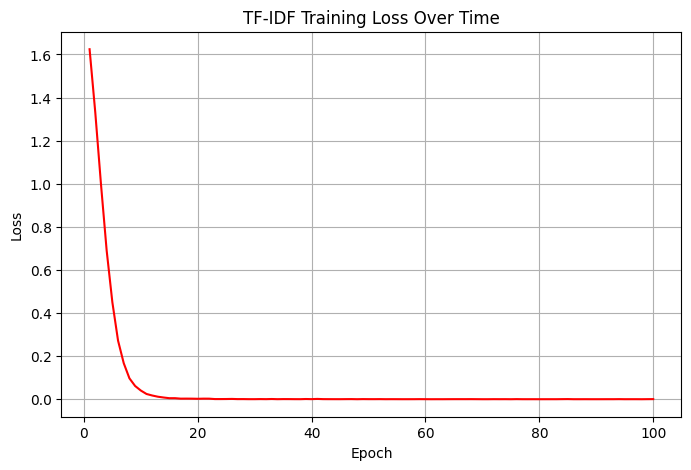

In [ ]:
plot.figure(figsize=(8,5))
plot.plot(range(1, epochs+1), losses_tfidf, color='red')
plot.xlabel("Epoch")
plot.ylabel("Loss")
plot.title("TF-IDF Training Loss Over Time")
plot.grid(True)
plot.show()

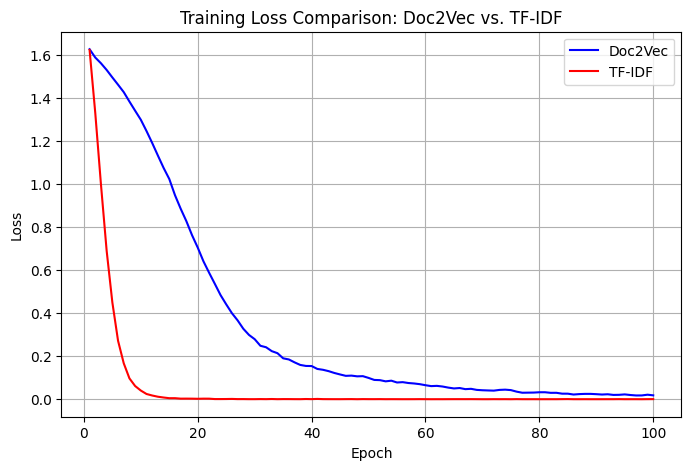

In [ ]:
plot.figure(figsize=(8, 5))
plot.plot(range(1, epochs+1), losses, color='blue', label='Doc2Vec')
plot.plot(range(1, epochs+1), losses_tfidf, color='red', label='TF-IDF')
plot.xlabel("Epoch")
plot.ylabel("Loss")
plot.title("Training Loss Comparison: Doc2Vec vs. TF-IDF")
plot.legend()
plot.grid(True)
plot.show()

# **Q3 (10pts)**
(1) Why Doc2Vec is necessary in this problem? Please explain.

A) Doc2Vec is necessary in this problem because neural networks are unable to process strings of text/rawtext. The BBC articles are originally full text documents that are not able to be fed into Neural Network Linear layers. Doc2Vec converts each article into a fixed-size vector of numbers that are able to better view the meaning and context of the words, which makes it possible for the FNN to accurately learn patterns AND classify articles into the right categories.

---


(2) Please discuss how you improve your training to get better results?

A) To improve my training results I made quite a few changes. My initial accuracy started at 85.17%. I began making incremental changes to items like my Doc2Vec vector size from 50 to 100, to 200 to 250, which helped the model gain a more detailed representation of each article. I also increased my Doc2Vec training epochs from 20 to 100, to allow for my embeddings to be better changed before feeding the data into the FNN. Third I fixed my learning rate back to 0.001 after experimenting with SGD as my optimizer instead of Adam which I had used previously in all my testing. Using SGD dropped my accuracy from 95%(with Adam) to 46%, so I immediately turned around on my decision. These changes improved my test accuracy to a 95.51%.